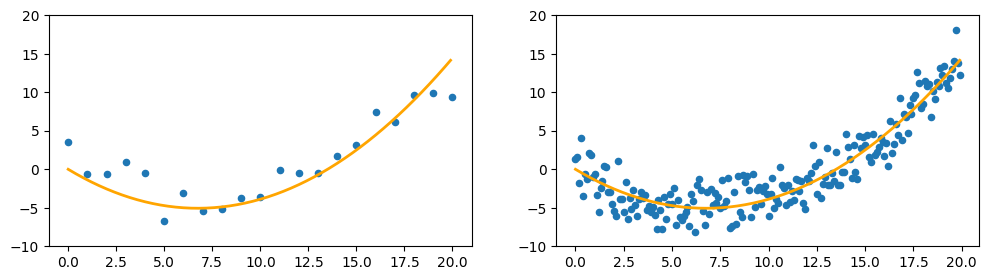

In [3]:
import numpy as np; np.random.seed(0); import matplotlib.pyplot as plt
w0 = 0; w1 = -1.5; w2 = 1/9; sigma = 2; f = lambda X: w0 + w1 * X + w2 * X * X
N = 21; X = np.linspace(0.0, 20, N); y = f(X) + np.random.normal(0, sigma, X.shape)
Xt = np.arange(0.0, 20, 0.1); yt = f(Xt) + np.random.normal(0, sigma, Xt.shape)
fig, axs = plt.subplots(1, 2, figsize=(12, 3))
ax = axs[0]; ax.set_ylim([-10, 20]); ax.scatter(X, y, s=20); ax.plot(Xt, f(Xt), c='orange', lw=2)
ax = axs[1]; ax.set_ylim([-10, 20]); ax.scatter(Xt, yt, s=20); ax.plot(Xt, f(Xt), c='orange', lw=2);


In [2]:
import numpy as np; np.set_printoptions(formatter={'float': lambda x: "{0:0.2f}".format(x)})
X = np.array([[1,0],[1,1],[1,1],[1,2]]); y = np.array([0,.5,1.5,2]); eta = .05; w = np.zeros(2)
for i in range(100):
    w = w - eta * 2.0*X.T@(X@w-y)
print(w)

[0.00 1.00]


hw = [0.00 1.00] RSS = 0.5
np.linalg.lstsq: hw = [0.00 1.00] RSS = 0.5


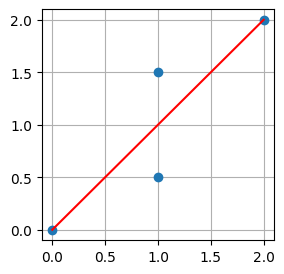

In [3]:
import numpy as np; import matplotlib.pyplot as plt
X = np.array([0.0, 1.0, 1.0, 2.0]); N = len(X); Xh = np.c_[np.ones(N), X]
y = np.array([0.0, 0.5, 1.5, 2.0]); hw = np.linalg.inv(Xh.T @ Xh) @ Xh.T @ y
y_pred = Xh @ hw; RSS = np.square(y - y_pred).sum(); print(f'hw = {hw} RSS = {RSS}')
[m, c], [r], _, _ = np.linalg.lstsq(np.c_[X, np.ones(N)], y, rcond=None)
print(f'np.linalg.lstsq: hw = {hw} RSS = {RSS}')
fig = plt.figure(figsize=(3, 3)); plt.plot(X, y, 'o'); plt.plot(X, m*X + c, 'r'); plt.grid(True)

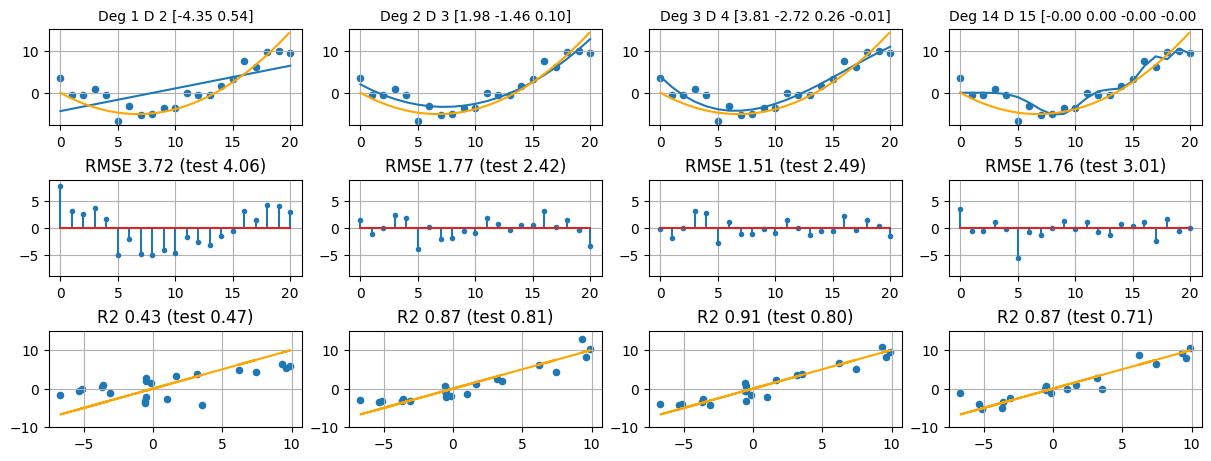

In [7]:
import numpy as np; np.random.seed(0); import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures; from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error as RMSE, r2_score as R2
w0 = 0; w1 = -1.5; w2 = 1/9; sigma = 2; f = lambda X: w0 + w1 * X + w2 * X * X
N = 21; X = np.linspace(0.0, 20, N); y = f(X) + np.random.normal(0, sigma, X.shape)
Xt = np.arange(0.0, 20, 0.1); yt = f(Xt) + np.random.normal(0, sigma, Xt.shape); degs = [1, 2, 3, 14]
fig, axs = plt.subplots(3, len(degs), figsize=(12, 4.5), constrained_layout=True)
for i, deg in enumerate(degs):
    poly = PolynomialFeatures(degree=deg, include_bias=True); Xp = poly.fit_transform(X.reshape(-1, 1))
    lr = LinearRegression(fit_intercept=False).fit(Xp, y); y_pred = lr.predict(Xp)
    Xtp = poly.transform(Xt.reshape(-1, 1)); yt_pred = lr.predict(Xtp)
    ax = axs.flat[i]; ax.grid(); ax.scatter(X, y, s=20); ax.plot(X, y_pred)
    ax.plot(Xt, f(Xt), color='orange'); ax.set_title(f'Deg {deg} D {Xp.shape[1]} {lr.coef_!s:.24s}', fontsize=10)
    ax = axs.flat[i+len(degs)]; ax.grid(); ax.set_ylim(-9, 9); ax.stem(X, y - lr.predict(Xp), markerfmt='.')
    ax.set_title(f'RMSE {RMSE(y, y_pred):.2f} (test {RMSE(yt, yt_pred):.2f})')
    ax = axs.flat[i+2*len(degs)]; ax.grid(); ax.set_ylim(-10, 15); ax.scatter(y, y_pred, s=20)
    ax.plot(y, y, color='orange'); ax.set_title(f'R2 {R2(y, y_pred):.2f} (test {R2(yt, yt_pred):.2f})')

In [8]:
import numpy as np
from sklearn.linear_model import LinearRegression
X = np.array([[1, 1], [1, 2], [2, 2], [2, 3]])
# y = 1 * x_0 + 2 * x_1 + 3
y = np.dot(X, np.array([1, 2])) + 3
reg = LinearRegression().fit(X, y)
print(reg.score(X, y))
print(reg.coef_)
print(reg.intercept_)
print(reg.predict(np.array([[3, 5]])))

1.0
[1.00 2.00]
3.0000000000000018
[16.00]


In [10]:
import numpy as np; import datasets; ds = datasets.load_dataset("scikit-learn/auto-mpg"); ds


README.md: 0.00B [00:00, ?B/s]

auto-mpg.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/398 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin', 'car name'],
        num_rows: 398
    })
})

In [11]:
import pandas as pd; df = ds['train'].to_pandas(); df.info()


<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(3), int64(4), str(2)
memory usage: 35.3 KB


In [12]:
df.drop(df[df.horsepower == "?"].index, inplace=True)
df = df.astype({'horsepower' : np.int64})
df['origin'] = df['origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})
df = df.astype({'origin' : 'category'})
df.drop('car name', axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           392 non-null    float64 
 1   cylinders     392 non-null    int64   
 2   displacement  392 non-null    float64 
 3   horsepower    392 non-null    int64   
 4   weight        392 non-null    int64   
 5   acceleration  392 non-null    float64 
 6   model year    392 non-null    int64   
 7   origin        392 non-null    category
dtypes: category(1), float64(3), int64(4)
memory usage: 24.9 KB


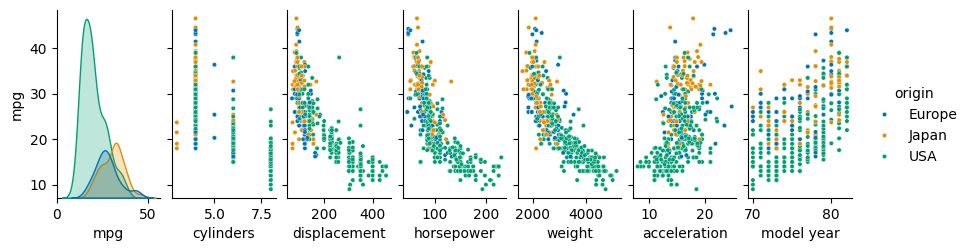

In [14]:
import seaborn as sns
sns.pairplot(df, y_vars='mpg', hue="origin", aspect=.5, palette='colorblind', plot_kws=dict(marker="o", s=10));

In [15]:
from sklearn.preprocessing import StandardScaler; from sklearn.model_selection import train_test_split
df = pd.concat([df, pd.get_dummies(df.origin, prefix='', prefix_sep='')], axis=1)
df.drop('origin', axis=1, inplace=True); y = df.pop('mpg'); X = df
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scaler = StandardScaler(); X_train = scaler.fit_transform(X_train); X_test = scaler.transform(X_test);

In [16]:
from sklearn.linear_model import LinearRegression; from sklearn.metrics import r2_score
linreg = LinearRegression().fit(X_train, y_train)
y_train_pred = linreg.predict(X_train); y_test_pred = linreg.predict(X_test)
r2_train = r2_score(y_train, y_train_pred); r2_test = r2_score(y_test, y_test_pred)

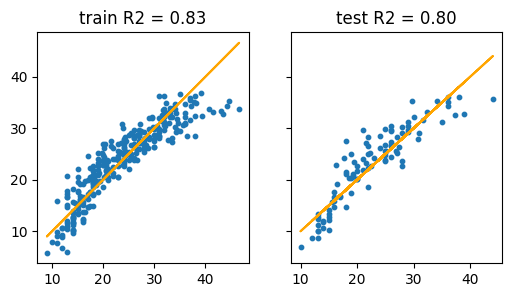

In [17]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey = 'all')
ax = axs[0]; ax.set_title(f'train R2 = {r2_train:.2f}')
ax.scatter(y_train, y_train_pred, s=10); ax.plot(y_train, y_train, color='orange')
ax = axs[1]; ax.set_title(f'test R2 = {r2_test:.2f}')
ax.scatter(y_test, y_test_pred, s=10); ax.plot(y_test, y_test, color='orange');

In [18]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(2); X_train = poly.fit_transform(X_train); X_test = poly.transform(X_test)
linreg = LinearRegression().fit(X_train, y_train)
y_train_pred = linreg.predict(X_train); y_test_pred = linreg.predict(X_test)
r2_train = r2_score(y_train, y_train_pred); r2_test = r2_score(y_test, y_test_pred)

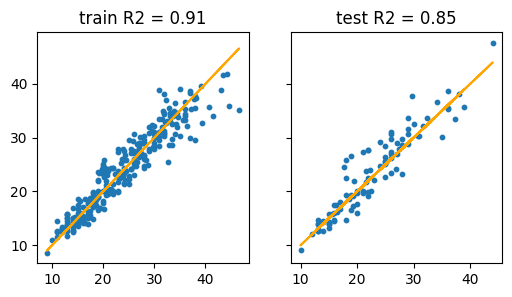

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey = 'all')
ax = axs[0]; ax.set_title(f'train R2 = {r2_train:.2f}')
ax.scatter(y_train, y_train_pred, s=10); ax.plot(y_train, y_train, color='orange')
ax = axs[1]; ax.set_title(f'test R2 = {r2_test:.2f}')
ax.scatter(y_test, y_test_pred, s=10); ax.plot(y_test, y_test, color='orange');

In [20]:
import numpy as np; import datasets; ds = datasets.load_dataset("scikit-learn/Fish"); ds

README.md:   0%|          | 0.00/567 [00:00<?, ?B/s]

Fish.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/159 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width'],
        num_rows: 159
    })
})

In [21]:
import pandas as pd; df = ds['train'].to_pandas(); df.info()


<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    str    
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), str(1)
memory usage: 9.6 KB


In [22]:
from sklearn.linear_model import LinearRegression; from sklearn.metrics import r2_score
linreg = LinearRegression().fit(X_train, y_train)
y_train_pred = linreg.predict(X_train); y_test_pred = linreg.predict(X_test)
r2_train = r2_score(y_train, y_train_pred); r2_test = r2_score(y_test, y_test_pred)

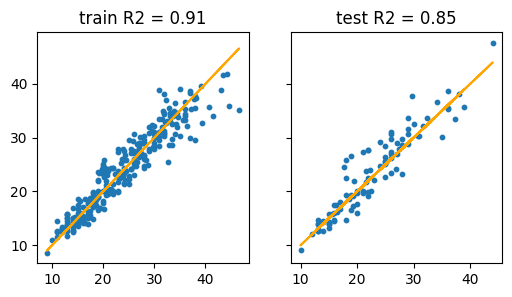

In [23]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey = 'all')
ax = axs[0]; ax.set_title(f'train R2 = {r2_train:.2f}')
ax.scatter(y_train, y_train_pred, s=10); ax.plot(y_train, y_train, color='orange')
ax = axs[1]; ax.set_title(f'test R2 = {r2_test:.2f}')
ax.scatter(y_test, y_test_pred, s=10); ax.plot(y_test, y_test, color='orange');


In [24]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(2); X_train = poly.fit_transform(X_train); X_test = poly.transform(X_test)
linreg = LinearRegression().fit(X_train, y_train)
y_train_pred = linreg.predict(X_train); y_test_pred = linreg.predict(X_test)
r2_train = r2_score(y_train, y_train_pred); r2_test = r2_score(y_test, y_test_pred)

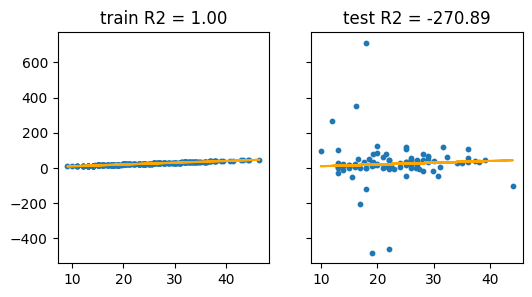

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey = 'all')
ax = axs[0]; ax.set_title(f'train R2 = {r2_train:.2f}')
ax.scatter(y_train, y_train_pred, s=10); ax.plot(y_train, y_train, color='orange')
ax = axs[1]; ax.set_title(f'test R2 = {r2_test:.2f}')
ax.scatter(y_test, y_test_pred, s=10); ax.plot(y_test, y_test, color='orange');